# **Multiple Linear Regression.**
## **Health Insurance Cost and Risk Dataset**
### **Problem Statement**:
The purpose of this project is to help health insurance providers better understand and predict individual medical costs in order to improve risk assessment and pricing decisions. The project uses demographic and health-related factors such as age, BMI, smoking status, sex, and region to build a model that estimates medical charges and identifies the key factors that influence healthcare expenses.

**Global imports**

In [1]:
#Data Manipulation
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset and Info**

In [2]:
#Imports
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
# Set the path to the file you'd like to load
file_path = "health_insurance_cost_and_risk_dataset.csv"

In [4]:
# Load the latest version
insur_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mjawad17/health-insurance-cost-and-risk-dataset",
  file_path)

100%|██████████| 98.0k/98.0k [00:00<00:00, 22.3MB/s]


In [5]:
insur_df.head()

,age,sex,bmi,children,smoker,region,charges,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19.0,female,27.900,0.0,yes,southwest,16884.92400,139.0,Never,True,high,104158.67
1,18.0,male,33.770,1.0,no,southeast,1725.55230,129.9,Weekly,True,moderate,43530.88
2,28.0,male,33.000,3.0,no,southeast,4449.46200,111.1,Rarely,False,high,113004.75
3,33.0,male,22.705,0.0,no,northwest,21984.47061,126.9,Rarely,False,high,185041.26
4,32.0,male,28.880,0.0,no,northwest,3866.85520,134.7,Rarely,True,low,46747.97


In [6]:
insur_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1337 non-null   float64
 1   sex                     1338 non-null   object 
 2   bmi                     1337 non-null   float64
 3   children                1337 non-null   float64
 4   smoker                  1338 non-null   object 
 5   region                  1338 non-null   object 
 6   charges                 1338 non-null   float64
 7   blood_pressure          1338 non-null   float64
 8   exercise_frequency      1338 non-null   object 
 9   pre_existing_condition  1338 non-null   bool   
 10  occupation_risk         1338 non-null   object 
 11  annual_income           1338 non-null   float64
dtypes: bool(1), float64(6), object(5)
memory usage: 116.4+ KB


## **1. Data Cleaning**

**a) Missing values**

In [7]:
insur_df.isnull().sum()

,0
age,1
sex,0
bmi,1
children,1
smoker,0
region,0
charges,0
blood_pressure,0
exercise_frequency,0
pre_existing_condition,0


In [8]:
#Drop Missing values
insur_df.dropna(inplace = True)

* Dropped missing values — only 2 rows affected.

**b) Check for duplicates**

In [9]:
insur_df.duplicated().sum()

np.int64(0)

*   No duplicates found



**c) Summary statistics to check value ranges and spot anomalies**

In [10]:
insur_df.describe()

,age,bmi,children,charges,blood_pressure,annual_income
count,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000
mean,39.187266,30.665404,1.097378,13255.381012,124.448764,114384.827401
std,14.034525,6.102598,1.205727,12104.185093,8.552669,49688.080485
min,18.000000,15.960000,0.000000,1121.873900,110.100000,30109.230000
25%,27.000000,26.302500,0.000000,4742.306100,117.400000,70844.485000
50%,39.000000,30.400000,1.000000,9377.904700,124.500000,114372.240000
75%,51.000000,34.700000,2.000000,16582.138605,131.400000,157206.265000
max,64.000000,53.130000,5.000000,63770.428010,140.000000,199966.140000


*   No negative or unrealistic values found across numeric columns.
*   Charges appear right-skewed — the mean is notably higher than the median,suggesting a few high-cost individuals pulling the average up.




## **2. Exploratory Data Analysis**

### ***a) EDA on Categorical Columns***

In [11]:
cat_cols = insur_df.select_dtypes(include = ['object','category','bool']).columns
cat_cols

Index(['sex', 'smoker', 'region', 'exercise_frequency',
       'pre_existing_condition', 'occupation_risk'],
      dtype='object')

***1). Sex column***

In [12]:
#unique values on sex column
insur_df['sex'].unique() #sex column has 2 unique values male and female

array(['female', 'male'], dtype=object)

***Visualization of sex column***

<Axes: xlabel='sex', ylabel='count'>

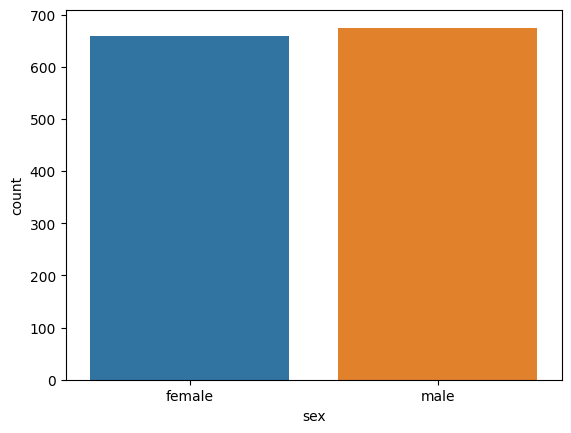

In [13]:
#count plot
sns.countplot(x = 'sex',data = insur_df,hue = 'sex') #almost same but men are slightly higher than womenm

In [14]:
insur_df['sex'].value_counts()

,count
sex,
male,675
female,660


<Axes: xlabel='sex', ylabel='charges'>

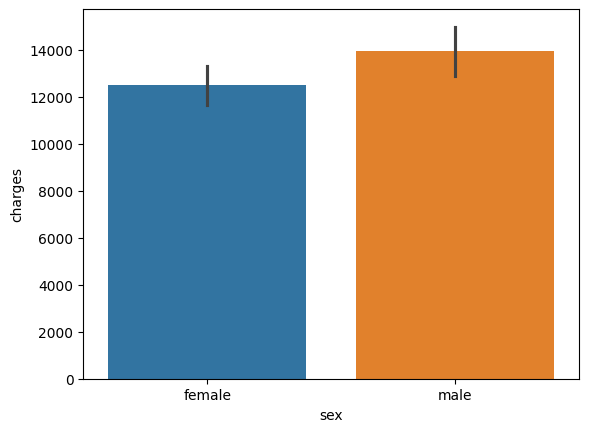

In [15]:
#bar plot of sex vs average charges
sns.barplot(x = 'sex',y = 'charges',data = insur_df,hue = 'sex') # difference in average spensong is small say about 10k

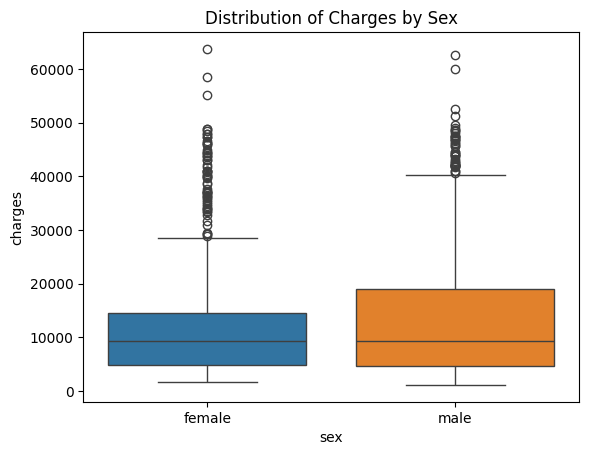

In [16]:
sns.boxplot(x='sex', y='charges',hue = 'sex' ,data=insur_df)
plt.title('Distribution of Charges by Sex')
plt.show()

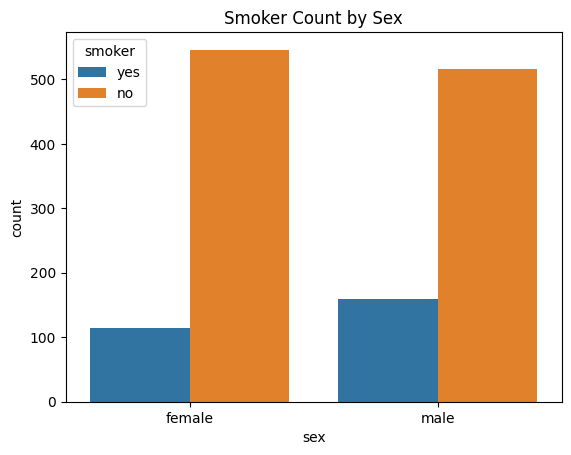

In [17]:
sns.countplot(x='sex', hue='smoker', data=insur_df)
plt.title('Smoker Count by Sex')
plt.show()

* The dataset is nearly balanced by sex (675 male, 660 female).
* Males have higher average charges than females, and given the overall charge range of $1,127 to $63,770, the ~$10,000 gap is a notable difference.

***2) Smoker column***

In [18]:
#unique values in this column
insur_df['smoker'].unique()

array(['yes', 'no'], dtype=object)

<Axes: xlabel='smoker', ylabel='count'>

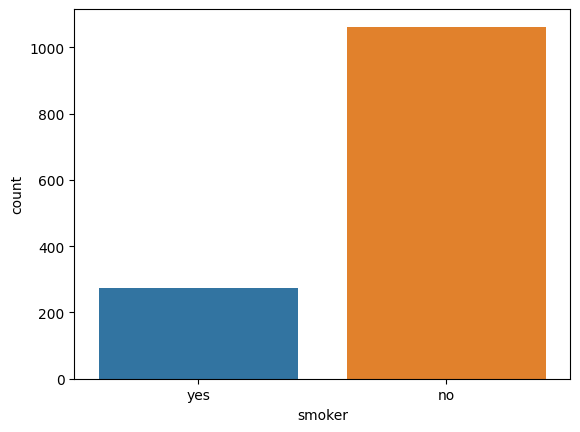

In [19]:
#countplot
sns.countplot(x = 'smoker',data = insur_df,hue = 'smoker') #more than half of the people in this dataset are non smokers

<Axes: xlabel='smoker', ylabel='charges'>

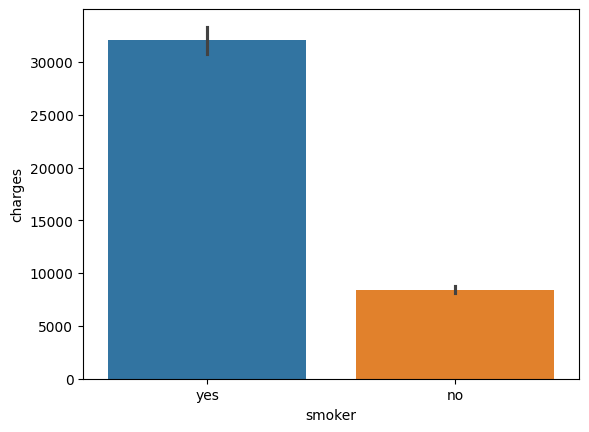

In [20]:
sns.barplot(x = 'smoker',y = 'charges',data = insur_df,hue = 'smoker') # average charges for smokers 33000 non smokers - 8000
#non smokers pay less

***3) Region column***

In [21]:
#Regions present in the dataset
insur_df['region'].value_counts() # 4 regions present in the datset. The region column is balanced around 350 people per region

,count
region,
southeast,364
southwest,324
northeast,324
northwest,323


<Axes: xlabel='region', ylabel='count'>

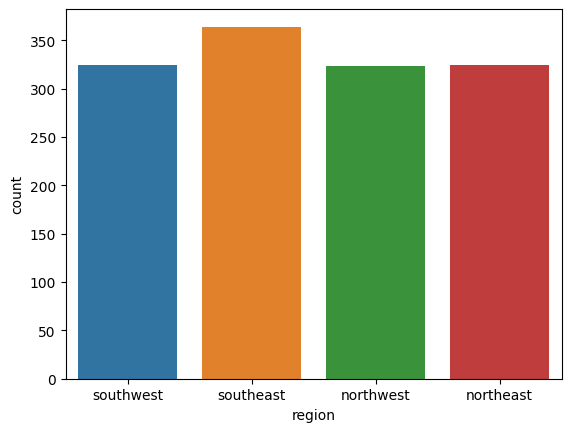

In [22]:
#Countplot
sns.countplot(x = 'region',data = insur_df,hue = 'region')

<Axes: xlabel='region', ylabel='charges'>

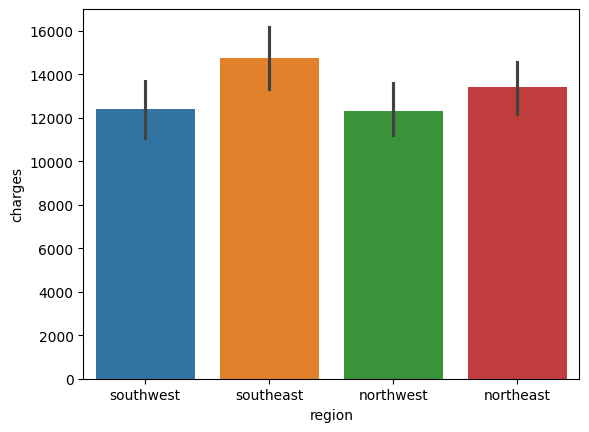

In [23]:
#barplot
sns.barplot(x = 'region',y = 'charges',data = insur_df,hue = 'region')

***4. Exercise frequency column***

In [24]:
insur_df['exercise_frequency'].value_counts() #balanced

,count
exercise_frequency,
Weekly,352
Daily,348
Rarely,333
Never,302


<Axes: xlabel='exercise_frequency', ylabel='charges'>

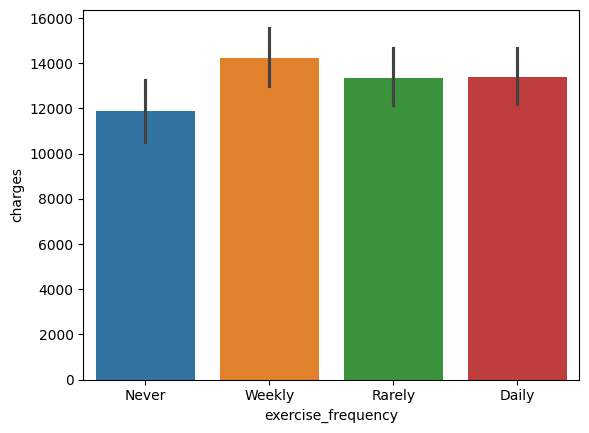

In [25]:
#bar plot
sns.barplot(x = 'exercise_frequency',y = 'charges',data = insur_df,hue = 'exercise_frequency')
#exercise weekly pay more 14200 error bar 2800
#rarely - 13500 error bar 3000
#daily - same as rarely 3000
#never - pay the lowest 11900 error bar  2500
#might not be a strong predictor of prices random rarely and daily have average charges
#how do you decide an error bar is huge

* Mean charges vary modestly across exercise frequency groups: Weekly (14,200),Rarely (13,500), Daily (13,400), and Never(11,900).

* Contrary to expectation, weekly exercisers show the highest mean charges rather than the 2nd lowest. Never exercisers show the lowest mean charges.

* However, all four groups have wide error bars (2,500–3,000) that overlap substantially with each other. This suggests the differences between groups are likely not statistically significant.

***5) Occupation risk column***

In [26]:
#unique values in the column
insur_df['occupation_risk'].value_counts() #balanced 470 441 and 424

,count
occupation_risk,
moderate,470
high,441
low,424


<Axes: xlabel='occupation_risk', ylabel='charges'>

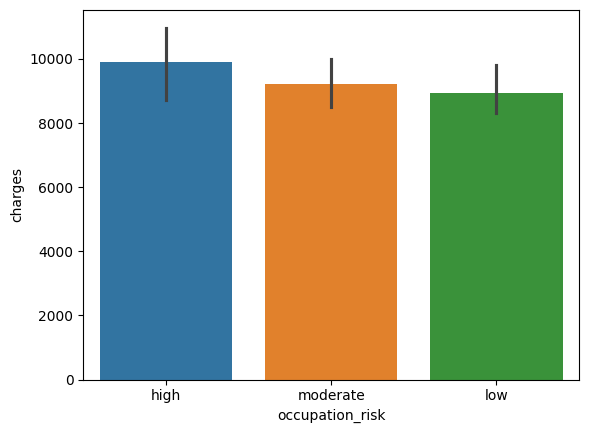

In [27]:
#barplot - does occupation risk impact charges
sns.barplot(x = 'occupation_risk',y = 'charges',data = insur_df,hue = 'occupation_risk',estimator=np.median)
# high risk pays an avergae charge that is higher than the rest - 10000 error bar - 2500
#moderate and low have the same average charges of around 9000 their error vars have the same length of 1500


* The median estimator was used in place of the mean due to the right-skewed distribution of charges.

* High-risk occupations show the highest median charges (~$10,000), while moderate (9,200) and low-risk (9,000) groups are nearly identical. This directional pattern is intuitive — higher occupational risk is associated with higher healthcare costs.

***6) Pre existing condition column***

In [28]:
insur_df['pre_existing_condition'].value_counts() #almost balanced

,count
pre_existing_condition,
False,690
True,645


In [29]:
#Relationship between pre existing condition and charges

<Axes: xlabel='pre_existing_condition', ylabel='charges'>

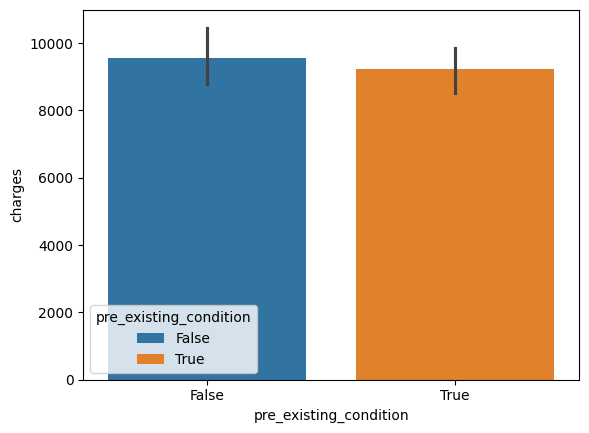

In [30]:
sns.barplot(x = 'pre_existing_condition',y = 'charges',data = insur_df,hue = 'pre_existing_condition',estimator=np.median)
#pay almost the same

# **Anova for Statistical Significance of Categorical Columns**

In [31]:
#imports
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats import anova

In [32]:
formula = 'charges ~ ' + ' + '.join([f' C({col})'for col in cat_cols])
model = ols(formula,insur_df).fit()
anova_table = anova.anova_lm(model,typ=2)
anova_table['PR(>F)'] = anova_table['PR(>F)'].round(3)

# Add a significance column: 'Yes' if p < 0.05, else 'No'
anova_table['Significant'] = anova_table['PR(>F)'].apply(lambda p: 'Yes' if p < 0.05 else 'No')
anova_table

,sum_sq,df,F,PR(>F),Significant
C(sex),1.612863e+06,1.0,0.029046,0.865,No
C(smoker),1.185685e+11,1.0,2135.308043,0.000,Yes
C(region),1.178561e+08,3.0,0.707493,0.548,No
C(exercise_frequency),3.880919e+08,3.0,2.329724,0.073,No
C(pre_existing_condition),3.094115e+07,1.0,0.557221,0.456,No
C(occupation_risk),8.302701e+07,2.0,0.747619,0.474,No
Residual,7.346300e+10,1323.0,NaN,NaN,No


* The above results are consistent with results from the bar graphs.
* **Smoker** is the only statistically significant predictor (F=2142.38, p<0.001).


***b) EDA on Categorical Columns***

In [33]:
num_cols = insur_df.select_dtypes(include = 'number').columns
num_cols

Index(['age', 'bmi', 'children', 'charges', 'blood_pressure', 'annual_income'], dtype='object')

**1) age column**

<Axes: xlabel='age', ylabel='Count'>

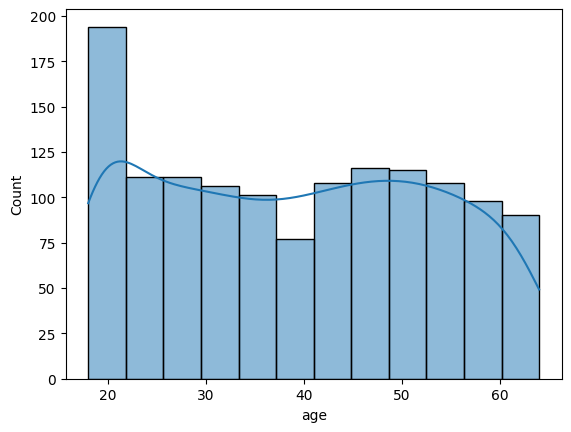

In [34]:
#takes on values between - 18 and 64
#Distribution of age
sns.histplot(x = 'age',data = insur_df,kde= True)

* Age is approximately uniformly distributed between 18 and 64, indicating good representation across all age groups. A notable spike at age 18–20 suggests possible oversampling of young adults or a minimum age threshold effect.

<Axes: xlabel='age', ylabel='charges'>

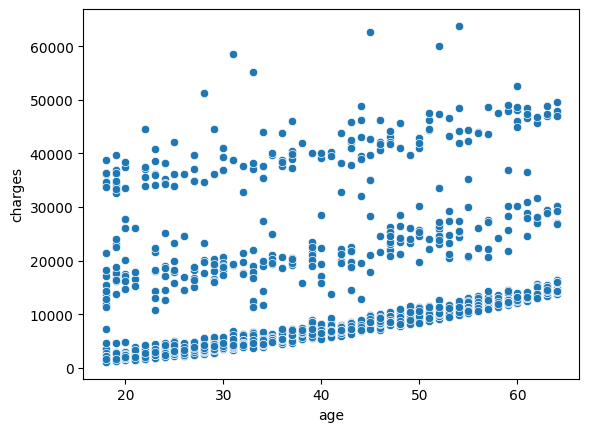

In [35]:
# Rship between age and charges
sns.scatterplot(x = 'age',y = 'charges',data = insur_df) # we can see 3 band from this plot. lets see what is causing the
#banding pattern

* The scatterplot reveals three distinct bands of charges across age groups, suggesting a strong interaction between age and other variables — most likely smoking status and BMI.
* Within each band, charges show a clear positive linear relationship with age, confirming that age is a meaningful predictor of medical costs. However the starting point and steepness of this relationship differs substantially across bands.

<Axes: xlabel='age', ylabel='charges'>

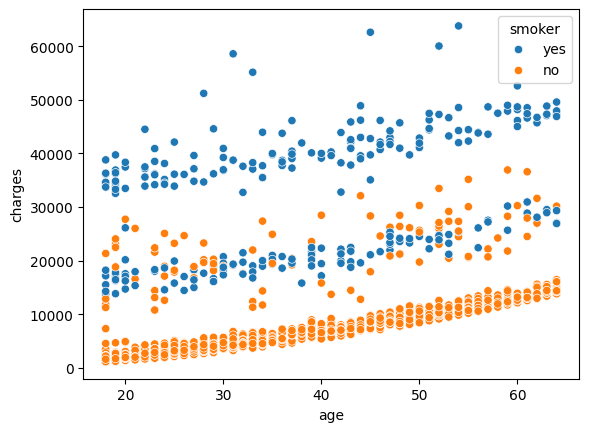

In [36]:
#INTERACTION BETWEEN AGE AND SMOKING STATUS
sns.scatterplot(x = 'age',y = 'charges',data = insur_df,hue='smoker')

* The bottom band is purely non smokers and the top band non smokers. But the middle band is a mix of both smokers and non smokers.
* Possible intercation between age and smokings status would be smoker * age - the middle band is left unexplained.

In [37]:
#INTERACTION BETWEEN AGE AND BMI
#BMI category variable
insur_df['bmi_category'] = pd.cut(insur_df['bmi'],
                             bins=[0, 18.5, 25, 30, float('inf')],
                             labels=['underweight', 'normal', 'overweight', 'obese'])

<Axes: xlabel='age', ylabel='charges'>

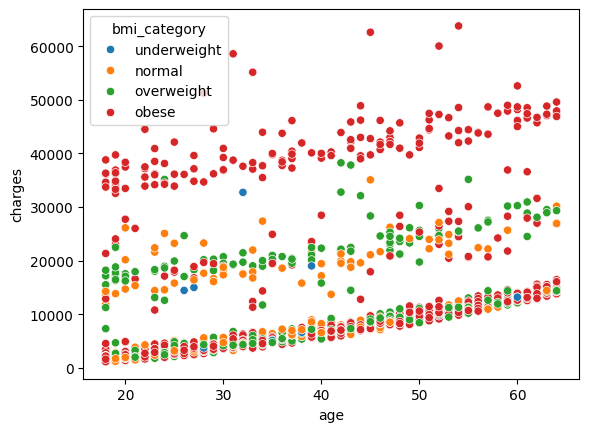

In [38]:

sns.scatterplot(x='age', y='charges', hue='bmi_category', data=insur_df)

* No clear separation of all bmi categories . obese indivuals present in all bands. - combine both bmi and smoking status on age.

<Axes: xlabel='age', ylabel='charges'>

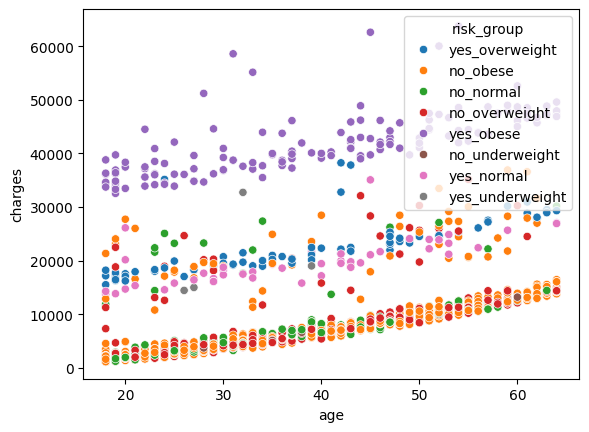

In [39]:
#INTERACTION OF BMI AND SMOKING STATUS ON AGE
insur_df['risk_group'] = insur_df['smoker'] + '_' + insur_df['bmi_category'].astype(str)

sns.scatterplot(x='age', y='charges', hue='risk_group', data=insur_df)

* Top band - obese smokers
* middle band - smokers who are not obese
* lower band - non smokers of all bmi categor - left unexplained are non smokers in the middle band. what pushes them to the midlle band.
* Possible interaction - age * bmi * smoker

***2) BMI column***

<Axes: xlabel='bmi', ylabel='Count'>

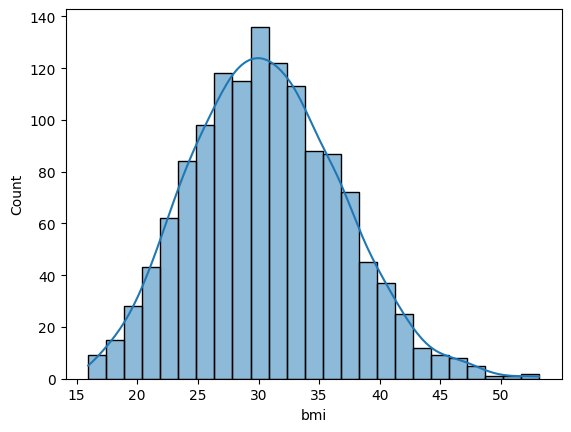

In [40]:
#min 15 max - 53 - continous varaible units - kg/m^2
#distribution of bmi
sns.histplot(x = 'bmi',data = insur_df,kde= True)
#perfect normal distribution

In [41]:
#Central tendency mean - 30 ,median - 30 std 6

<Axes: xlabel='bmi', ylabel='charges'>

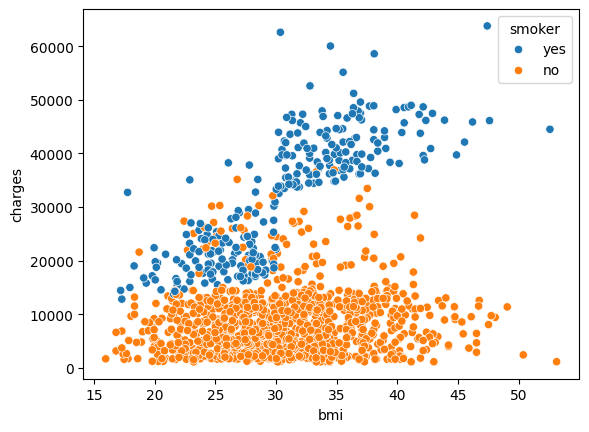

In [42]:
#Relationship between bmi and charges
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=insur_df)

* A scatterplot of BMI against charges coloured by smoking status reveals two-tier structure that directly confirms the interaction
effect between BMI and smoking.

* Non-smokers form a flat cluster at low charges (~$0–$20,000)
regardless of BMI level. This indicates that BMI has almost no independent relationship with charges for non-smokers — their costs remain low and stable even at high BMI values.

* Smokers show a markedly different pattern — a clear positive linear
relationship between BMI and charges, with costs rising steeply as BMI increases. This confirms that BMI only becomes a meaningful driver of medical costs in the presence of smoking.
* possible ineteraction- smoker * bmi

***3) Children***

In [43]:
insur_df['children'].value_counts() # children has discrete varaibles convert to category

,count
children,
0.0,571
1.0,324
2.0,240
3.0,157
4.0,25
5.0,18


In [44]:
insur_df['children'] = insur_df['children'].astype('category')

<Axes: xlabel='children', ylabel='count'>

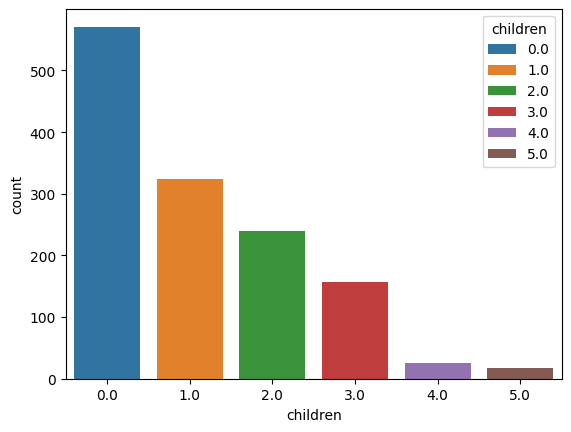

In [45]:
#Distribution of children column
sns.countplot(x = 'children',data = insur_df,hue= 'children')
#people with no children dominate the dataset almost half

<Axes: xlabel='children', ylabel='charges'>

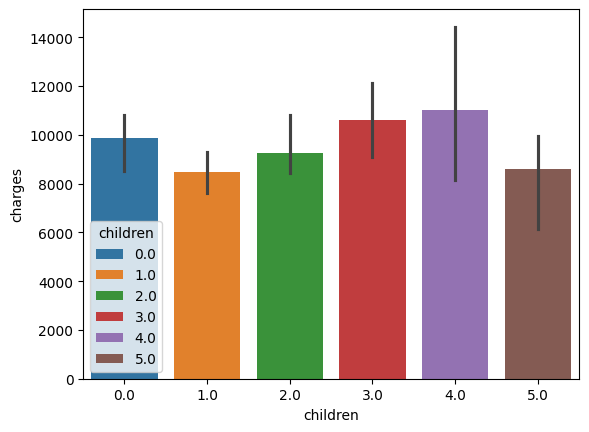

In [46]:
#relationship of children column with target
sns.barplot(x = 'children',y = 'charges',data = insur_df,hue= 'children',estimator = np.median)
#huge error bars with median used
#5 children pay the lowest - counterintuitive we expect more charges more children
#4 children pay the highest
#error bars overlap might not ve significant
#

In [47]:
cat_cols.to_list().append('children')
model = ols('charges ~ C(children)',insur_df).fit()
anova_table = anova.anova_lm(model,typ=2)
anova_table['PR(>F)'] = anova_table['PR(>F)'].round(3)
anova_table['Significant'] = anova_table['PR(>F)'].apply(lambda p: 'Yes' if p < 0.05 else 'No')
anova_table

,sum_sq,df,F,PR(>F),Significant
C(children),2.436301e+09,5.0,3.355109,0.005,Yes
Residual,1.930098e+11,1329.0,NaN,NaN,No


In [48]:
ss_children = anova_table.loc['C(children)', 'sum_sq']
ss_residual = anova_table.loc['Residual', 'sum_sq']

eta_squared = ss_children / (ss_children + ss_residual)
print(f"Eta squared: {eta_squared:.4f}")

Eta squared: 0.0125


ANOVA returned a statistically significant result for number of children
(p < 0.05). However effect size analysis reveals eta squared = 0.0125,
meaning children accounts for only 1.25% of the variation in medical
charges — a small and practically negligible effect. drop children its not practically significant

In [49]:
#DRop children column


***4) Blood pressure column***

<Axes: xlabel='blood_pressure', ylabel='Count'>

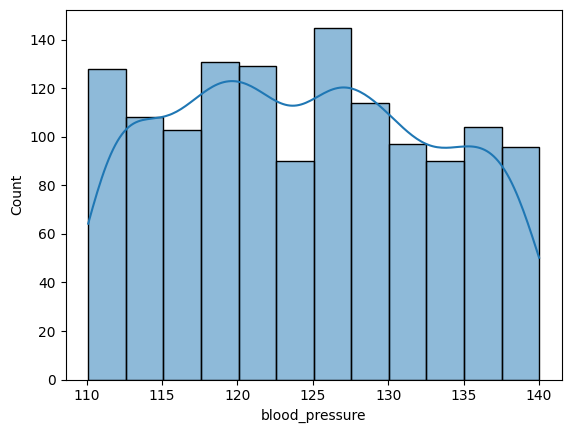

In [50]:
#Distribution of blood pressure column
sns.histplot(x = 'blood_pressure',data = insur_df,kde= True)

<Axes: xlabel='blood_pressure', ylabel='charges'>

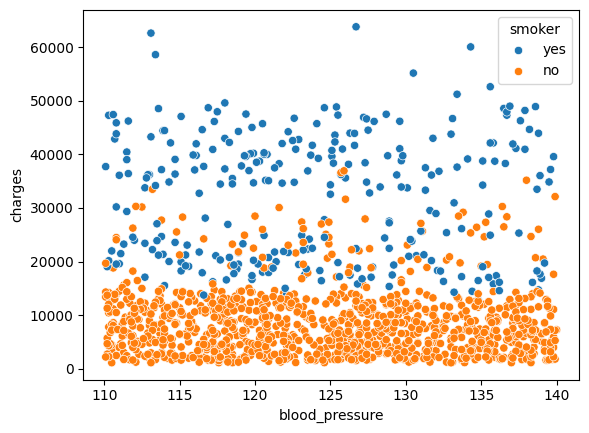

In [51]:
#Relationship between blood pressure and target variable
sns.scatterplot(x = 'blood_pressure',y = 'charges',data = insur_df,hue = 'smoker')

In [52]:
insur_df[['blood_pressure','charges']].corr()

,blood_pressure,charges
blood_pressure,1.000000,-0.039284
charges,-0.039284,1.000000


* There is no meaningful relationship between blood pressure and charges supported by a near zero correlation of -0.03.
* The scatterplot also revealed a banding pattern in charges that is explained by smoking.
* This shows that it doesnt matter what your blood pressure is, if you smoke you pay dramatically more.

***6) Annual income column***

In [53]:
insur_df['annual_income'].describe()

,annual_income
count,1335.000000
mean,114384.827401
std,49688.080485
min,30109.230000
25%,70844.485000
50%,114372.240000
75%,157206.265000
max,199966.140000


<Axes: xlabel='annual_income', ylabel='Count'>

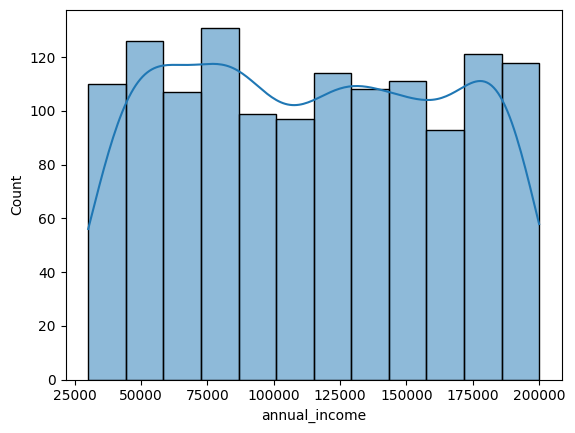

In [54]:
# Distribution of annual income
sns.histplot(x = 'annual_income',data = insur_df,kde= True)

<Axes: xlabel='annual_income', ylabel='charges'>

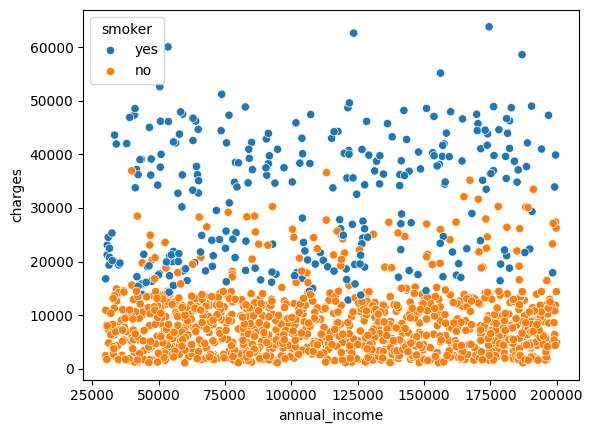

In [55]:
#Relationship between annual income and charges
sns.scatterplot(x = 'annual_income',y = 'charges',data = insur_df,hue = 'smoker')

In [56]:
insur_df[['annual_income','charges']].corr()

,annual_income,charges
annual_income,1.000000,0.002932
charges,0.002932,1.000000


* Same story as blood pressure no meaningful rship with charges supported by both the scatterplot a near zero correlation of 0.02.
* A banding pattern is also revealed showing that no matter what you earn if you smoke you still pay more.

In [57]:
insur_df.select_dtypes(include='number').corr()

,age,bmi,charges,blood_pressure,annual_income
age,1.000000,0.111271,0.296372,-0.081912,-0.002874
bmi,0.111271,1.000000,0.200196,-0.051079,0.000418
charges,0.296372,0.200196,1.000000,-0.039284,0.002932
blood_pressure,-0.081912,-0.051079,-0.039284,1.000000,-0.038621
annual_income,-0.002874,0.000418,0.002932,-0.038621,1.000000


# **3. Data Encoding**

fit model with all and then with sex only and age and bmi

In [58]:
cat_cols

Index(['sex', 'smoker', 'region', 'exercise_frequency',
       'pre_existing_condition', 'occupation_risk'],
      dtype='object')

In [59]:
#sex column
insur_df['sex_enc'] = insur_df['sex'].map({'male':1,'female':0})
insur_df['sex_enc'].value_counts()

,count
sex_enc,
1,675
0,660


In [60]:
#drop original sex column
insur_df.drop('sex',axis =1,inplace = True)

In [61]:
#smoker column
insur_df['smoker_enc'] = insur_df['smoker'].map({'yes':1,'no':0})
insur_df['smoker'].value_counts()

,count
smoker,
no,1062
yes,273


In [62]:
#drop original smoker column
insur_df.drop('smoker',axis =1,inplace = True)

In [63]:
#region column - one hot encode
region_dummies = pd.get_dummies(insur_df['region'],drop_first = True,dtype = int)

In [64]:
#concat region  dummies to insurdf
insur_df = pd.concat([region_dummies,insur_df],axis = 1)

In [65]:
#drop original region column
insur_df.drop('region',axis =1,inplace = True)

In [66]:
#encode occupation risk - ordinal encode
#imports
from sklearn.preprocessing import OrdinalEncoder
occ_risk_enc = OrdinalEncoder(categories = [['low','moderate','high']])
insur_df['occupation_risk_enc'] =occ_risk_enc.fit_transform(insur_df[['occupation_risk']])

In [67]:
#drop original occupation risk column
insur_df.drop('occupation_risk',axis =1,inplace = True)

In [68]:
#bmi_category
bmi_encoder = OrdinalEncoder(categories = [['underweight','normal','overweight','obese']])
insur_df['bmi_enc'] = bmi_encoder.fit_transform(insur_df[['bmi_category']])

In [69]:
#Encode exercise frequency - ordinal encode
exercise_freq_enc = OrdinalEncoder(categories = [['Never','Rarely','Weekly','Daily']])
insur_df['exercise_frequency_enc'] =exercise_freq_enc.fit_transform(insur_df[['exercise_frequency']])

In [70]:
insur_df['exercise_frequency_enc'].value_counts()

,count
exercise_frequency_enc,
2.0,352
3.0,348
1.0,333
0.0,302


In [71]:
#drop original exercise frequency column
insur_df.drop('exercise_frequency',axis =1,inplace = True)

In [72]:
#pre existing condition column
insur_df['pre_existing_condition_enc'] = insur_df['pre_existing_condition'].astype(int)

In [73]:
insur_df['pre_existing_condition_enc'].value_counts()

,count
pre_existing_condition_enc,
0,690
1,645


In [74]:
#drop original pre existing condition  column
insur_df.drop('pre_existing_condition',axis =1,inplace = True)

In [75]:
insur_df.columns

Index(['northwest', 'southeast', 'southwest', 'age', 'bmi', 'children',
       'charges', 'blood_pressure', 'annual_income', 'bmi_category',
       'risk_group', 'sex_enc', 'smoker_enc', 'occupation_risk_enc', 'bmi_enc',
       'exercise_frequency_enc', 'pre_existing_condition_enc'],
      dtype='object')

# **4. Split into target ,base features and extended features**

In [76]:
y = insur_df['charges']

In [77]:
base_features = insur_df[['age','bmi','smoker_enc']]

In [78]:
extended_feature_names = ['age', 'bmi', 'smoker_enc', 'blood_pressure', 'annual_income','sex_enc',
                          'occupation_risk_enc', 'exercise_frequency_enc','pre_existing_condition_enc','northwest',
                          'southeast', 'southwest','children']

extended_features = insur_df[extended_feature_names]

In [79]:
#Mean centre continous varibales to reduce structural multicollinearity
insur_df['age_centered'] = insur_df['age'] - insur_df['age'].mean()
# insur_df['bmi_centered'] = insur_df['bmi'] - insur_df['bmi'].mean()

# Add interaction terms with centered variables
insur_df['age_smoker'] = insur_df['age_centered'] * insur_df['smoker_enc']
insur_df['bmi_smoker'] = insur_df['bmi_enc'] * insur_df['smoker_enc']
insur_df['age_bmi'] = insur_df['age_centered'] * insur_df['bmi_enc']
insur_df['age_bmi_nonsmoker'] = insur_df['age_centered'] * insur_df['bmi_enc'] * (1 - insur_df['smoker_enc'])

In [80]:
interaction_extended_features = insur_df[['age', 'smoker_enc', 'bmi_enc','annual_income',
    'sex_enc', 'exercise_frequency_enc', 'southeast',
    'southwest', 'children', 'age_smoker', 'bmi_smoker']]



In [81]:
interaction_base_features = insur_df[['age', 'bmi_enc', 'smoker_enc','age_smoker', 'bmi_smoker','age_bmi']]

# **5. Multicollinearity Check**

In [82]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
X_vif = sm.add_constant(interaction_base_features)
vif_df = pd.DataFrame()
vif_df['Features'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values,i) for i in range (X_vif.shape[1])]
vif_df


,Features,VIF
0,const,80.532378
1,age,9.947443
2,bmi_enc,1.304876
3,smoker_enc,8.944679
4,age_smoker,1.260727
5,bmi_smoker,9.178857
6,age_bmi,9.668691


* VIF values are all less than 5% indicating no multicollinearity concerns in the model

# **6. Transform y variable if necessary**

In [83]:
y_transformed = np.sqrt(y)

# **6. Split Dataset into train and test set**

In [84]:
#imports
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(interaction_extended_features,y_transformed,test_size = 0.3,random_state = 42)

# **6. Linear Regression model**

**1) Build Model**

In [85]:
#imports
from sklearn.linear_model import LinearRegression

In [86]:
linreg = LinearRegression()
linreg.fit(X_train,y_train)

LinearRegression()

**2) Model Prediction**

In [87]:
#Train set prediction
y_train_pred = linreg.predict(X_train)
y_train_org = y_train ** 2
y_train_pred_org = y_train_pred ** 2

In [88]:
#Train set prediction
y_test_pred = linreg.predict(X_test)
y_test_org = y_test ** 2
y_test_pred_org = y_test_pred ** 2

**3) Model Perfomance**

***a) Train set perfomance***

In [89]:
#Imports
from sklearn.metrics import mean_squared_error,r2_score

In [90]:
train_r2 = r2_score(y_train_org,y_train_pred_org)
train_mse = mean_squared_error(y_train_org,y_train_pred_org)
train_rmse = np.sqrt(train_mse)

In [91]:
print(f"Train R2 score: {train_r2:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")

Train R2 score: 0.857
Train RMSE: 4574.396


***b) Test set perfomance***

In [92]:
test_r2 = r2_score(y_test_org,y_test_pred_org)
test_mse = mean_squared_error(y_test_org,y_test_pred_org)
test_rmse = np.sqrt(test_mse)

**4) . Model Coefficients**

In [93]:
print(f"Test R2 score: {test_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")

Test R2 score: 0.828
Test RMSE: 5020.908


**5) Model Assumption Check**

***a) Normality Assumption***

In [94]:
#Calculate Residuals
train_residuals = y_train - y_train_pred

<Axes: xlabel='charges', ylabel='Count'>

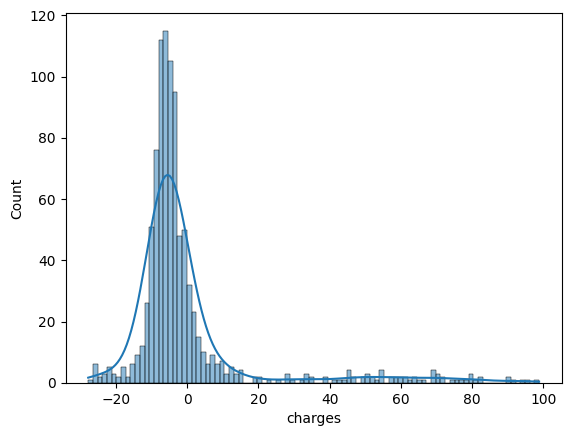

In [95]:
#Distribution of residuals
sns.histplot(x = train_residuals,kde = True)

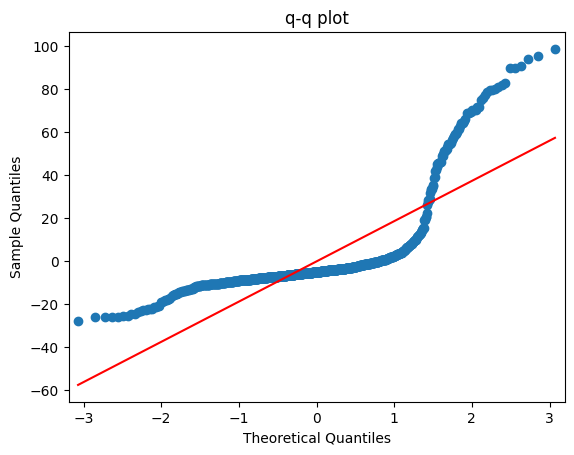

In [96]:
import statsmodels.api as sm
sm.qqplot(train_residuals,line = 's')
plt.title('q-q plot')
plt.show() #Normality assumption violated

***b) Constant Variance Assunption***

Text(0, 0.5, 'residual)')

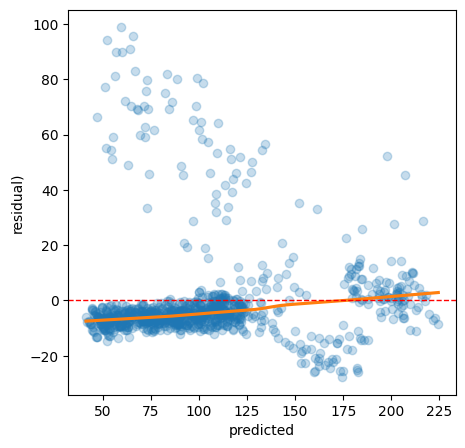

In [97]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=y_train_pred, y=train_residuals,
            scatter_kws={'alpha': 0.25}, line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('predicted')
ax.set_ylabel('residual)') #Non linearity present

<Axes: xlabel='charges'>

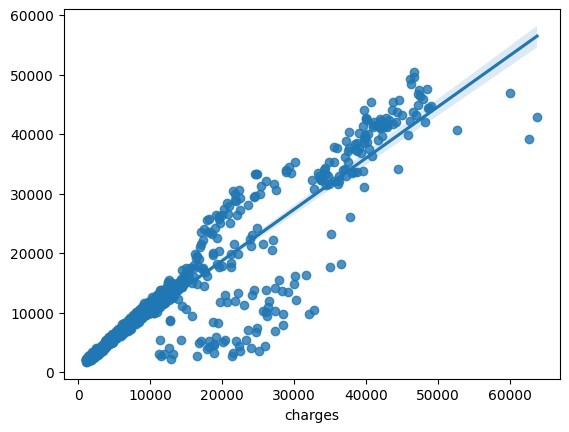

In [98]:
sns.regplot(x = y_train_org,y = y_train_pred_org) #How to interpret this regplot

* The cluster at the lower part of the line might indicate a missing predictor for non smokers.

***c) Model Coefficients***

In [99]:
#Standardize coeff
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
#to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns, index=X_test.index)

In [101]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_scaled)
model = sm.OLS(y_train, X_sm).fit()
robust = model.get_robustcov_results(cov_type='HC3')

print(robust.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     760.9
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:45:18   Log-Likelihood:                -4061.3
No. Observations:                 934   AIC:                             8147.
Df Residuals:                     922   BIC:                             8205.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    104

* The key drivers of charges are BMI-smoking interaction, age, smoking status and age smoking interaction.
* It is worth noting that BMI only matters for smokers. i.e bmi alone does not affect charges.
* Smoking status is a key driver not just directly, but because it amplifies the effect of BMI. A smoker with high BMI faces dramatically higher charges than either a non-smoker with high BMI or a smoker with normal BMI.
* Age increases charges for everyone, but less so for smokers (net effect: +16 vs +22 for non-smokers) since smoking already has a high baseline cost.




* Dependent variable(charges) were transformed to address non-linearity in the model
* Heteroscedasticity was detected and addressed using
  robust standard errors (HC3), ensuring significance
  tests and confidence intervals remain reliable
* R² = 0.848 — model explains 85% of variation in charges
* However smoker subgroup R² = 79% vs
  non-smoker subgroup R² = 39%
* This gap suggests a meaningful predictor
  of non-smoker charges is absent from the dataset
* Heteroscedasticity likely reflects this missing
  information rather than a modelling problem
* Recommended: collect more detailed health
  condition data for non-smokers